# Libraries

In [15]:
from functions import *
from UQpy.distributions import Normal, JointIndependent
# Do you want plot with latex font format? Use the cell bellow:
import matplotlib as mpl
mpl.rcParams.update({
                        'font.family': 'serif',
                        'mathtext.fontset': 'cm',
                        'axes.unicode_minus': False
                    })
import seaborn as sns
import numpy as np

# Dataset

### $R$ and $S$ realization

In [16]:
n_samples = 1
n_latent_samples = 5000
time = [0., 10., 20., 30., 40., 50., 60., 70., 80., 90., 100.]
r   = Normal(loc = 5., scale=0.8)
s   = Normal(loc = 2., scale=0.6)
joint = JointIndependent(marginals=[r, s])
x = joint.rvs(n_samples)
x

array([[5.09227903, 1.79807679]])

### $g$ over the time

In [17]:
lambdas = []
gs = []
for k in time:
    y, df = state_limit_function_time(x, n_latent_samples, t=k)
    lambdas.append(y)
    gs.append(df[0])

In [18]:
lambdas = np.vstack(lambdas)
lambdas

array([[ 3.30708147,  6.65525335,  0.0852429 ,  0.13787515],
       [ 2.95172672,  6.7800739 ,  0.09944249,  0.15935331],
       [ 2.585235  ,  6.98102518,  0.10985941,  0.14421042],
       [ 2.23805757,  6.96088599,  0.11431722,  0.18186867],
       [ 1.8831452 ,  7.35851052,  0.08298313,  0.15818781],
       [ 1.52232661,  7.13638864,  0.1321867 ,  0.20140627],
       [ 1.16454512,  7.74974631,  0.08507133,  0.18475543],
       [ 0.81242568,  8.13417626,  0.08076732,  0.16603991],
       [ 0.4509099 ,  8.08780685,  0.08572384,  0.17489065],
       [ 0.09448038,  7.98754154,  0.10157033,  0.18676589],
       [-0.25728477,  8.25316594,  0.08954198,  0.20825865]])

In [34]:
# =========================
# Estatísticas por coluna
# =========================

# Média de cada coluna
media_lambdas = np.mean(lambdas, axis=0)

# Desvio padrão de cada coluna
std_lambdas = np.std(lambdas, axis=0)

# Coeficiente de variação (CV)
cv_lambdas = std_lambdas / media_lambdas

# =========================
# Impressão dos resultados
# =========================

for i in range(lambdas.shape[1]):
    print(
        f"Lambda {i+1}: "
        f"média = {media_lambdas[i]:.6f}, "
        f"desvio padrão = {std_lambdas[i]:.6f}, "
        f"CV = {cv_lambdas[i]:.2%}"
    )


Lambda 1: média = 1.522968, desvio padrão = 1.127605, CV = 74.04%
Lambda 2: média = 7.462234, desvio padrão = 0.567566, CV = 7.61%
Lambda 3: média = 0.096973, desvio padrão = 0.015531, CV = 16.02%
Lambda 4: média = 0.173056, desvio padrão = 0.021270, CV = 12.29%


# Chart

### $g$ over the time

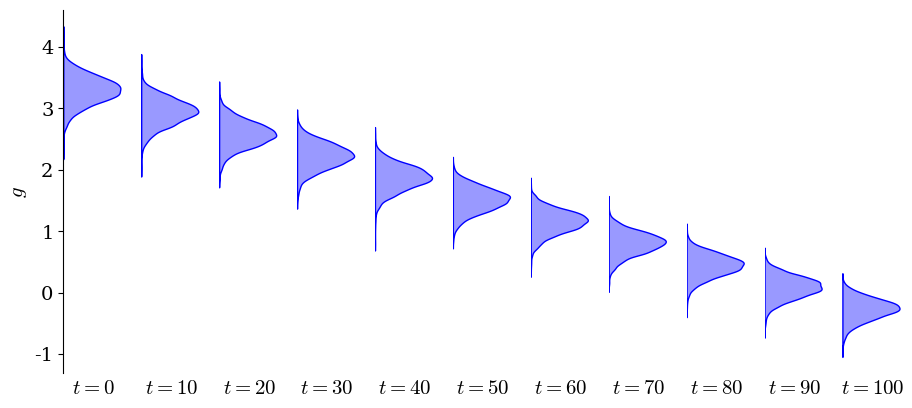

In [75]:
### Figure name and DPI
dpi = 600
name = 'time-lapse_g_analysis'

### Chart dimensions
b_cm_individual = 2.5      
h_cm = 12                 
inches_to_cm = 1 / 2.54

n_plots = len(time) 
b_input_total = (b_cm_individual * n_plots) * inches_to_cm
h_input = h_cm * inches_to_cm

### Axis and labels
label_y = '$g$'
size_label = 15
color_label = 'black'
size_axis = 14
color_axis = 'black'
color = 'blue'
alpha = 0.4

### Figure
fig, axes = plt.subplots(nrows=1, ncols=n_plots, sharey=True, figsize=(b_input_total, h_input))

### Space between plots
plt.subplots_adjust(wspace=0.3) 

### Loop
for i, ax in enumerate(axes):
    
    ### Plot
    current_data = gs[i]
    sns.kdeplot(y=current_data['g'], fill=True, alpha=alpha, ax=ax, color=color)
    
    # Configurações gerais (Fonte, Cor)
    ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
    
    # Label X
    ax.set_xlabel(f'$t={int(time[i])}$', fontsize=size_label, color=color_label)
    
    # Remove ticks e números do eixo X (como você pediu antes)
    ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

    # Remove bordas padrão (Topo, Direita, Baixo)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    # --- AQUI ESTÁ A MÁGICA PARA REMOVER O EIXO Y DOS OUTROS ---
    if i == 0:
        # Primeiro gráfico: Mantém a linha da esquerda e o Label Y
        ax.spines['left'].set_visible(True)
        ax.set_ylabel(label_y, fontsize=size_label, color=color_label)
    else:
        # Do segundo em diante:
        ax.spines['left'].set_visible(False)   # Remove a linha vertical
        ax.tick_params(axis='y', left=False)   # Remove os tracinhos (ticks) da esquerda
        ax.set_ylabel('')                      # Remove o label
        
### Save and Show
fig.savefig(f'z_{name}_en.png', dpi=dpi, bbox_inches='tight')
plt.show()

### $\lambda$ over the time

In [76]:
y1 = lambdas[:,0]
y2 = lambdas[:,1]
y3 = lambdas[:,2]
y4 = lambdas[:,3]
data = [
        {'x': time, 'y': y1},
        {'x': time, 'y': y2},
        {'x': time, 'y': y3},
        {'x': time, 'y': y4}
    ]

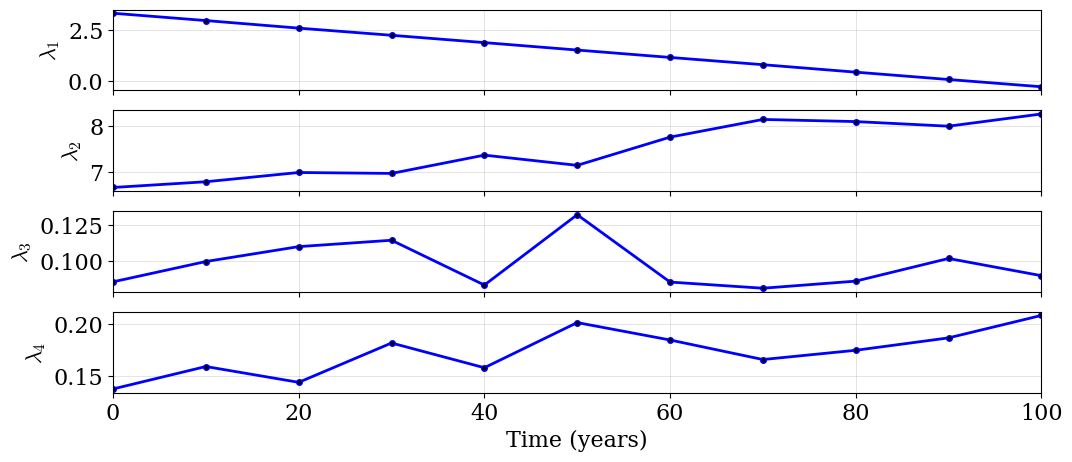

In [77]:
### Figure name and DPI
dpi = 600
name = 'lambdas_for_r_s_realization'

### Axis and labels
label_x = 'Time (years)'  
size_label = 16
color_label = 'black'
size_axis = 16
color_axis = 'black'

### Line
size_line = 2
style_line = '-'
color_line = 'blue'

### Marker
marker = 'o'
size_marker = 4
color_marker = 'black'
color_marker_edge = color_line

### Legend
labels_legend = ['$\lambda _1$', '$\lambda _2$', '$\lambda _3$', '$\lambda _4$']  # Change as you wish
size_legend = 18
location_legend = 'upper right'

### Grid
on_or_off = False
line_width_grid = 0.5
alpha_grid = 0.3
style_grid = '-'
color_grid = 'gray'

### Figure
fig, axes = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(b_input_total, h_input))

### Plot
i = 0
for ax, dataset in zip(axes, data):
    
    ax.plot(dataset['x'], dataset['y'],
            markerfacecolor=color_marker, marker=marker, markersize=size_marker,
            linewidth=size_line, linestyle=style_line, color=color_line)
    
    # Configuração dos Eixos (Cores e Tamanhos)
    ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
    
    # Label Y (Específico de cada gráfico, mas com seu estilo)
    ax.set_ylabel(labels_legend[i], fontsize=size_label, color=color_label)
    i += 1
    
    # Configuração do Grid
    ax.grid(on_or_off, which='both', linestyle=style_grid, linewidth=line_width_grid, color=color_grid, alpha=alpha_grid)
    
    # # Legenda
    # ax.legend(fontsize=size_legend, loc=location_legend)

# Ajuste específico para a Tangente (índice 2) pois ela vai ao infinito
# axes[2].set_ylim(-3, 3)
axes[0].set_xlim(0, 100)
axes[1].set_xlim(0, 100)
axes[2].set_xlim(0, 100)
axes[3].set_xlim(0, 100)

# Label X apenas no último gráfico
axes[-1].set_xlabel(label_x, fontsize=size_label, color=color_label)

# Ajustar espaçamento
plt.tight_layout()

# --- 6. SALVAR E MOSTRAR ---
fig.savefig(f'z_{name}_en.png', dpi=dpi, bbox_inches='tight')
plt.show()

### Ground truth versus GLAM

#### Ground Truth t = 0 years

In [58]:
gt_data = list(gs[0]['g'])

#### PCE t = 0 years

In [59]:
lambda_3 = list(lambdas[:,2])
lambda_3 = np.mean(lambda_3)
lambda_3

0.09697333144014278

In [60]:
lambda_4 = list(lambdas[:,3])
lambda_4 = np.mean(lambda_4)
lambda_4

0.17305564924782335

In [61]:
x

array([[5.09227903, 1.79807679]])

In [62]:
import pickle
with open('pce_metamodel_0.pkl', 'rb') as f:
    pce_metamodel = pickle.load(f)

y_val_pre = pce_metamodel.predict(x)
y_val_pre

array([[3.30338122, 6.62968919, 0.10937675, 0.15155117]])

In [63]:
lambdas_aux = [y_val_pre[0,0], y_val_pre[0,1], lambda_3, lambda_4]
lambdas_aux

[3.303381221719666,
 6.6296891907522495,
 0.09697333144014278,
 0.17305564924782335]

In [64]:
def glam_generator(lambdas, n_points=5000, quantile_trim=1e-3, qp_min=1e-8, ylim=None):
    l1, l2, l3, l4 = lambdas

    # Curva da PDF GLD (robusta para evitar explosões numéricas)
    a = float(quantile_trim)
    u = np.linspace(a, 1.0 - a, n_points)
    x = gld_fkml_quantile(u, l1, l2, l3, l4)
    qp = gld_fkml_qprime(u, l2, l3, l4)

    mask = np.isfinite(x) & np.isfinite(qp) & (qp > qp_min)
    x, f = x[mask], (1.0 / qp[mask])

    order = np.argsort(x)
    x, f = x[order], f[order]

    return list(x), list(f)

glam_data, _ = glam_generator(lambdas_aux) 

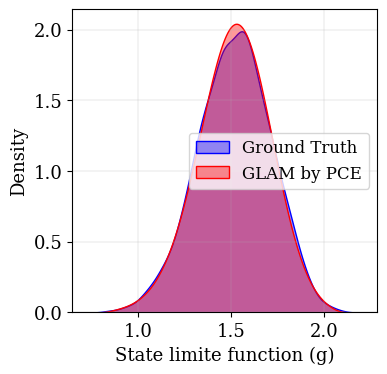

In [74]:
### Figure name and DPI
dpi = 600                                                                               # Change as you wish
name = 'histogram_glam_versus_gt_t0_en' # Change as you wish

### Chart dimensions (in centimeters)
b_cm = 10                                                   # Change as you wish
h_cm = 10                                                    # Change as you wish
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm

### Axis and labels (For LateX font format use the dollar sign $)
label_y = 'Density'
label_x = 'State limite function (g)'                     # Change as you wish     
size_label = 13                     # Change as you wish
color_label = 'black'               # or hexadecimal. Change as you wish
size_axis = 13                      # Change as you wish
color_axis = 'black'                # or hexadecimal. Change as you wish

### Color KDE
color = ['blue', 'red']             # or hexadecimal. Change as you wish
alpha = 0.4                         # Change as you wish

### Legend. Do you need legend? Use the cell bellow:
legend_label = ['Ground Truth', 'GLAM by PCE']    # Change as you wish
size_legend = 12                       # Change as you wish
location_legend = 'center right'       # Change as you wish

### Figure
fig, ax = plt.subplots(figsize=(b_input, h_input))

### Config axis
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)

### Config grid
on_or_off = True
plt.grid(on_or_off, which='both', linestyle='-', linewidth=0.2)

### Plot with legend
sns.kdeplot(data=gt_data, fill=True, alpha=alpha, ax=ax, color=color[0], label=legend_label[0])
sns.kdeplot(data=glam_data, fill=True, alpha=alpha, ax=ax, color=color[1], label=legend_label[1])
### Legend. Do you need legend? Use the cell bellow:
ax.legend(fontsize=size_legend, loc=location_legend)

# Save. Do you need save? Use the cell bellow:
fig.savefig(f'z_{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()

In [78]:
from scipy.stats import ks_2samp

# =========================
# Teste de Kolmogorov-Smirnov
# =========================

alpha = 0.05  # nível de significância (5%)

ks_stat, p_value = ks_2samp(gt_data, glam_data)

print("Kolmogorov-Smirnov Test")
print(f"KS statistic = {ks_stat:.6f}")
print(f"p-value      = {p_value:.6e}")

if p_value > alpha:
    print("Resultado: NÃO rejeita H0 → distribuições estatisticamente equivalentes.")
else:
    print("Resultado: Rejeita H0 → distribuições estatisticamente diferentes.")


Kolmogorov-Smirnov Test
KS statistic = 0.010800
p-value      = 9.325416e-01
Resultado: NÃO rejeita H0 → distribuições estatisticamente equivalentes.


In [79]:
from scipy.stats import anderson_ksamp

ad_result = anderson_ksamp([gt_data, glam_data])

print("\nAnderson-Darling k-sample Test")
print(f"Statistic = {ad_result.statistic:.6f}")
print(f"p-value   = {ad_result.significance_level/100:.4f}")



Anderson-Darling k-sample Test
Statistic = -0.649209
p-value   = 0.0025


#### Ground Truth t = 50 years

In [66]:
gt_data = list(gs[5]['g'])

#### PCE t = 50 years

In [67]:
lambda_3 = list(lambdas[:,2])
lambda_3 = np.mean(lambda_3)
lambda_3

0.09697333144014278

In [68]:
lambda_4 = list(lambdas[:,3])
lambda_4 = np.mean(lambda_4)
lambda_4

0.17305564924782335

In [69]:
import pickle
with open('pce_metamodel_50.pkl', 'rb') as f:
    pce_metamodel = pickle.load(f)

y_val_pre = pce_metamodel.predict(x)
y_val_pre

array([[1.52206077, 7.54660476, 0.09547005, 0.16747822]])

In [70]:
lambdas_aux = [y_val_pre[0,0], y_val_pre[0,1], lambda_3, lambda_4]
lambdas_aux

[1.5220607701963484,
 7.546604763532676,
 0.09697333144014278,
 0.17305564924782335]

In [71]:
def glam_generator(lambdas, n_points=5000, quantile_trim=1e-3, qp_min=1e-8, ylim=None):
    l1, l2, l3, l4 = lambdas

    # Curva da PDF GLD (robusta para evitar explosões numéricas)
    a = float(quantile_trim)
    u = np.linspace(a, 1.0 - a, n_points)
    x = gld_fkml_quantile(u, l1, l2, l3, l4)
    qp = gld_fkml_qprime(u, l2, l3, l4)

    mask = np.isfinite(x) & np.isfinite(qp) & (qp > qp_min)
    x, f = x[mask], (1.0 / qp[mask])

    order = np.argsort(x)
    x, f = x[order], f[order]

    return list(x), list(f)

glam_data, _ = glam_generator(lambdas_aux) 

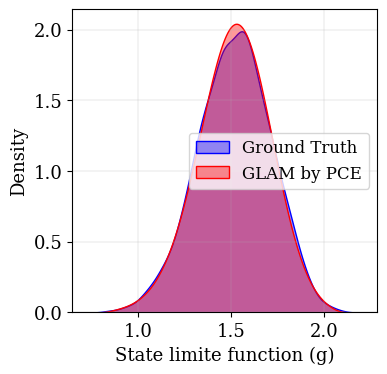

In [73]:
### Figure name and DPI
dpi = 600                                                                               # Change as you wish
name = 'histogram_glam_versus_gt_t50_en' # Change as you wish

### Chart dimensions (in centimeters)
b_cm = 10                                                   # Change as you wish
h_cm = 10                                                    # Change as you wish
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm

### Axis and labels (For LateX font format use the dollar sign $)
label_y = 'Density'
label_x = 'State limite function (g)'                     # Change as you wish     
size_label = 13                     # Change as you wish
color_label = 'black'               # or hexadecimal. Change as you wish
size_axis = 13                      # Change as you wish
color_axis = 'black'                # or hexadecimal. Change as you wish

### Color KDE
color = ['blue', 'red']             # or hexadecimal. Change as you wish
alpha = 0.4                         # Change as you wish

### Legend. Do you need legend? Use the cell bellow:
legend_label = ['Ground Truth', 'GLAM by PCE']    # Change as you wish
size_legend = 12                       # Change as you wish
location_legend = 'center right'       # Change as you wish

### Figure
fig, ax = plt.subplots(figsize=(b_input, h_input))

### Config axis
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)

### Config grid
on_or_off = True
plt.grid(on_or_off, which='both', linestyle='-', linewidth=0.2)

### Plot with legend
sns.kdeplot(data=gt_data, fill=True, alpha=alpha, ax=ax, color=color[0], label=legend_label[0])
sns.kdeplot(data=glam_data, fill=True, alpha=alpha, ax=ax, color=color[1], label=legend_label[1])
### Legend. Do you need legend? Use the cell bellow:
ax.legend(fontsize=size_legend, loc=location_legend)

# Save. Do you need save? Use the cell bellow:
fig.savefig(f'z_{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()

In [80]:
from scipy.stats import ks_2samp

# =========================
# Teste de Kolmogorov-Smirnov
# =========================

alpha = 0.05  # nível de significância (5%)

ks_stat, p_value = ks_2samp(gt_data, glam_data)

print("Kolmogorov-Smirnov Test")
print(f"KS statistic = {ks_stat:.6f}")
print(f"p-value      = {p_value:.6e}")

if p_value > alpha:
    print("Resultado: NÃO rejeita H0 → distribuições estatisticamente equivalentes.")
else:
    print("Resultado: Rejeita H0 → distribuições estatisticamente diferentes.")


Kolmogorov-Smirnov Test
KS statistic = 0.010800
p-value      = 9.325416e-01
Resultado: NÃO rejeita H0 → distribuições estatisticamente equivalentes.


In [81]:
from scipy.stats import anderson_ksamp

ad_result = anderson_ksamp([gt_data, glam_data])

print("\nAnderson-Darling k-sample Test")
print(f"Statistic = {ad_result.statistic:.6f}")
print(f"p-value   = {ad_result.significance_level/100:.4f}")



Anderson-Darling k-sample Test
Statistic = -0.649209
p-value   = 0.0025


In [ ]:
#Comparar quantis extremos

qs = [0.001, 0.01, 0.5, 0.99, 0.999]

for q in qs:
    print(
        f"q={q:.3f} | "
        f"GT={np.quantile(gt_data, q):.4f} | "
        f"GLAM={np.quantile(glam_data, q):.4f}"
    )


q=0.001 | GT=0.8995 | GLAM=0.9037
q=0.010 | GT=1.0387 | GLAM=1.0393
q=0.500 | GT=1.5222 | GLAM=1.5198
q=0.990 | GT=1.9374 | GLAM=1.9356
q=0.999 | GT=2.0529 | GLAM=2.0263
